# Segmentação de imagens utilizando clusterização k-médias

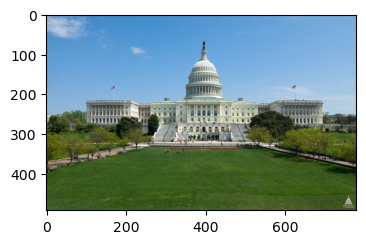

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import skimage.color
from sklearn.cluster import KMeans

img = plt.imread("../../dados/capitol.jpg")
plt.imshow(img)

## 1. K-médias no espaço de cor RGB

[[ 61.94536446  83.66269074  33.43726062]
 [123.58214335 173.66466045 216.88069544]
 [136.0284495  141.33927324 130.44533816]]


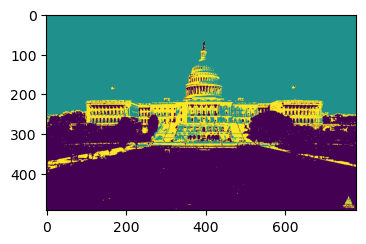

In [ ]:
def clusterize(img, num_clusters):
    """Aplica o algoritmo de k-médias para segmentar a imagem em num_clusters clusters.
    Retorna um array de rótulos (labels) e um array de centros dos clusters.
    """

    rows, cols, num_channels = img.shape

    # Redimensiona a imagem, formando um array onde cada linha é um
    # pixel e cada coluna é um atributo (cores do pixel)
    data = img.reshape(rows * cols, num_channels)

    # Cria instância da classe KMeans e ajusta aos dados
    km = KMeans(n_clusters=num_clusters, random_state=0)
    km.fit(data)

    # Obtém o rótulo de cada pixel. labels é um array 1D de tamanho
    # igual ao número de pixels na imagem
    labels = km.predict(data)

    # Redimensiona o array labels para o mesmo número de linhas
    # e colunas do array img
    img_labels = labels.reshape(rows, cols)

    centers = km.cluster_centers_

    return img_labels, centers

img_labels, centers = clusterize(img, num_clusters=3)

print(centers)
plt.imshow(img_labels)

### Mostrando cada rótulo em uma imagem separada

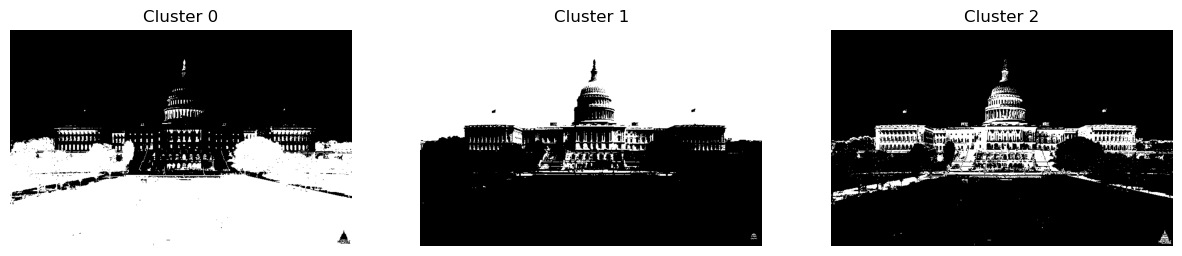

In [63]:
def show_clusters(img_labels):

    num_clusters = np.max(img_labels)+1
    fig, axes = plt.subplots(1, num_clusters, figsize=(15, 5))
    for c in range(num_clusters):
        axes[c].imshow(img_labels==c, "gray")
        axes[c].set_title(f"Cluster {c}")
        axes[c].axis("off")

show_clusters(img_labels)

Note que no resultado acima, se obtivermos o maior componente conexo e realizarmos operações adequadas de abertura e fechamento, o resultado será bem razoável.

### Mostrando os rótulos na cor original

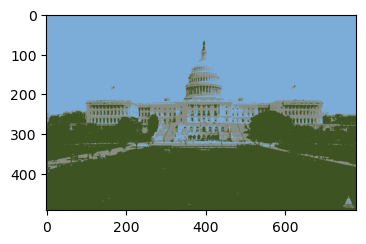

In [64]:
def show_clusters_color(img_labels, centers):

    num_rows, num_cols = img_labels.shape
    num_clusters = len(centers)

    # Para cada canal, substituímos os pixels brancos da imagem segmentada
    # pelo valor do centróide do respectivo cluster
    img_reconst = np.zeros((num_rows, num_cols, 3), dtype=np.uint8)
    for c in range(num_clusters):
        img_mask = img_labels==c
        
        # A linha abaixo possui o significado: para cada pixel em
        # img_reconst onde img_mask é True, coloque o valor RGB do 
        # centróide do cluster possuindo índice c
        img_reconst[img_mask] = centers[c]

    plt.imshow(img_reconst)

show_clusters_color(img_labels, centers)

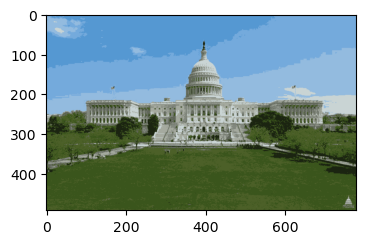

In [72]:
def clusterize_and_show(img, num_clusters):

    img_labels, centers = clusterize(img, num_clusters)
    show_clusters_color(img_labels, centers)

clusterize_and_show(img, num_clusters=10)

## 2. K-médias no espaço de cores L\*a\*b\*

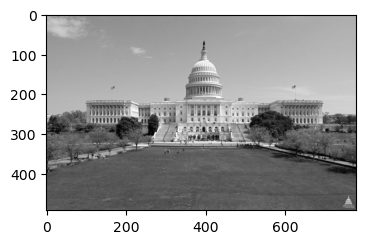

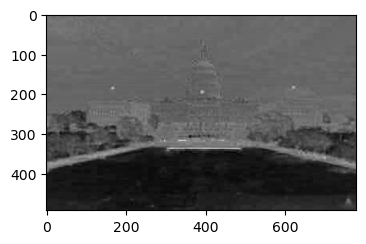

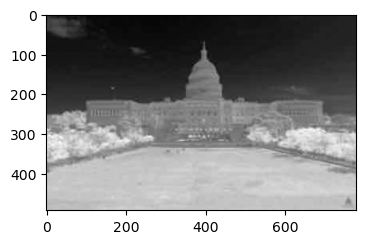

In [73]:
# Transforma espaço de cores de RGB para Lab. Esse espaço
# possui três canais de cores: L, a e b
img_lab = skimage.color.rgb2lab(img)
# O mesmo comando utilizando OpenCV seria
#img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)

for i in range(3):
    plt.figure()
    plt.imshow(img_lab[:,:,i], "gray")

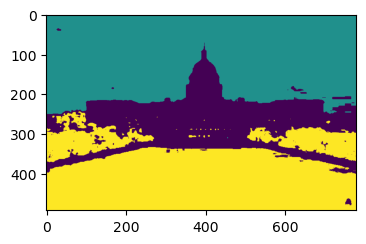

In [74]:
# Vamos utilizar apenas os canais a e b. O canal L em geral 
# não é utilizado para a clusterização
img_l, img_ab = img_lab[:,:,0], img_lab[:,:,1:3]

img_labels, centers = clusterize(img_ab, num_clusters=3)

plt.imshow(img_labels)

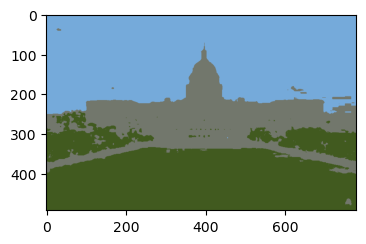

In [75]:
def reconstruct_img_from_lab(img_l, img_labels, centers):
    """Reconstrói a imagem RGB a partir do resultado da segmentação k-médias. 
       Os parâmetros de entrada são o canal L da imagem no espaço Lab (img_L), 
       um array 2D contendo em cada posição o rótulo do pixel (img_labels) e 
       a cor, nos canais a e b, associada a cada rótulo (centers)"""

    num_rows, num_cols = img_labels.shape

    img_reconst = np.zeros((num_rows, num_cols, 3))
    for c in range(len(centers)):
        ind = np.nonzero(img_labels==c)
        
        # Precisamos calcular um valor médio do canal L para associar 
        # a cada cluster
        avg_lightness = np.mean(img_l[ind[0],ind[1]])
        img_reconst[ind[0], ind[1], 0] = avg_lightness
        img_reconst[ind[0], ind[1], 1] = centers[c][0]
        img_reconst[ind[0], ind[1], 2] = centers[c][1]

    img_rgb = skimage.color.lab2rgb(img_reconst)

    return img_rgb


img_rgb = reconstruct_img_from_lab(img_l, img_labels, 
                                   centers)

    
plt.imshow(img_rgb)